# 02 · Understanding the data

Before choosing what to analyse, it is worth asking what this data actually contains: how responses
divide, how values are distributed, whether the four metrics move together, and whether any of them
is measuring something different from the rest.

Each question below is paired with the chart form that answers it, **the form follows the question**:

| Question | Form used | Why that form |
|---|---|---|
| How does one question's responses divide? | **Donut** | Genuine part-to-whole, only four segments |
| How are the percentages distributed? | **Histogram** | Shows shape, spread and outliers |
| How do expectations move over time? | **Line** | Progression along an ordered axis |
| Do the four metrics move together? | **Heatmap + scatter** | Pairwise association across many cells |

## Setup

In [ ]:
import sys
from pathlib import Path

# Walk up until src/csbc.py is found, so the notebook runs whether Jupyter was started
# in the project root or in src/. Nothing here depends on an absolute path.
_here = Path.cwd().resolve()
_root = next(p for p in (_here, *_here.parents) if (p / "src" / "csbc.py").exists())
sys.path.insert(0, str(_root / "src"))

import pandas as pd
import matplotlib.pyplot as plt

import csbc

csbc.ensure_dirs()
csbc.apply_chart_theme()

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 48)

print(f"project: {csbc.ROOT.name}/")
print(f"raw data: {len(sorted(csbc.RAW_DIR.glob('*.csv')))} quarterly CSVs in data/raw")

project: business_data_lab_assignment/
raw data: 4 quarterly CSVs in data/raw


In [ ]:
csbc_data = csbc.load_combined()
QUARTERS = csbc.sort_quarters(csbc_data["Quarter"])

print(f"{len(csbc_data):,} rows | quarters: {', '.join(QUARTERS)}")

9,408 rows | quarters: Q3 2023, Q4 2023, Q1 2024, Q2 2024


## The shape of the data

The data is **long**: one row per answer, with four categorical dimensions and a single numeric
column. That matters for the correlation question later, you cannot correlate `GEO` against
`VALUE`, so the data has to be reshaped before that question can even be asked.

In [ ]:
print(f"rows: {len(csbc_data):,}   columns: {list(csbc_data.columns)}\n")
print("one survey cell = one group x one metric, holding three rows:")
csbc_data[
    (csbc_data["GEO"] == "Canada")
    & (csbc_data["Business_characteristics"] == csbc.ALL_INDUSTRIES)
    & (csbc_data["Business_information"] == "Sales")
    & (csbc_data["Quarter"] == "Q1 2024")
][["Business_information", "Expected_change", "VALUE", "Quarter"]]

rows: 9,408   columns: ['GEO', 'Business_characteristics', 'Business_information', 'Expected_change', 'VALUE', 'Quarter']

one survey cell = one group x one metric, holding three rows:


,Business_information,Expected_change,VALUE,Quarter
3,Sales,increase,17.8,Q1 2024
4,Sales,stay about the same,63.1,Q1 2024
5,Sales,decrease,15.3,Q1 2024


## Question 1: How do responses divide within a question?

**Form: donut.** Four segments that genuinely sum to a whole, which is the one case where a
part-to-whole circle beats a bar. The fourth segment is the share giving **no directional answer**,
the gap left when the three published shares do not reach 100.

Q1 2024 is used rather than Q2 2024 because Q1 is complete; Q2 is the quarter with seven missing
cells.

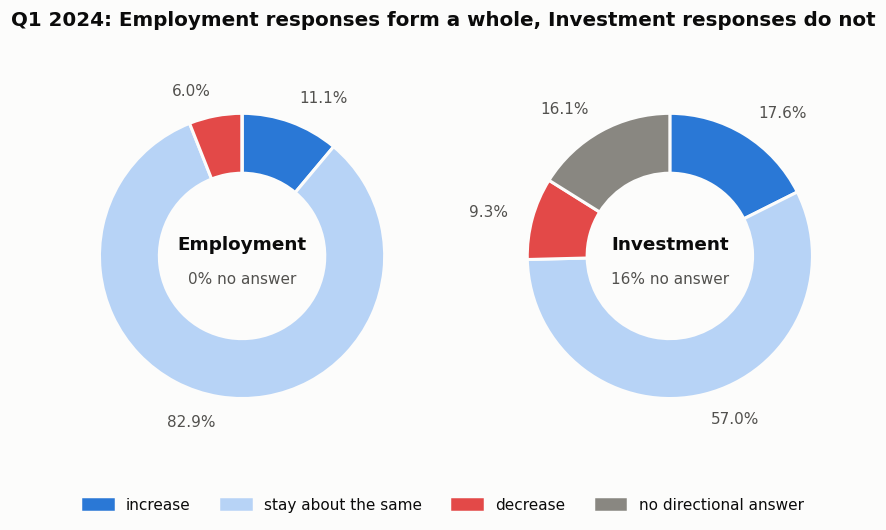

Expected_change,increase,stay about the same,decrease,no directional answer
Business_information,,,,
Employment,11.1,82.9,6.0,0.0
Investment,17.6,57.0,9.3,16.1


In [ ]:
csbc.response_donuts(
    csbc_data, "Q1 2024", metrics=("Employment", "Investment"),
    output_path=csbc.OUTPUT_DIR / "eda_response_composition.png",
)

**This is the single most important thing in the dataset.**

Employment's three responses account for **every** business: 11.1 + 82.9 + 6.0 = 100. Investment's
account for only about 84, leaving **16% of businesses giving no directional answer at all**.

The most likely reason is mundane and important: many businesses, especially small ones, have no
investment plan to report, so there is no direction to give. Employment, by contrast, is something
every operating business can answer.

Consequence: **the residual cannot be redistributed**, and the four metrics cannot be pooled into a
single index, because they do not even share a denominator.

In [ ]:
# The same comparison across all four metrics, as numbers.
csbc.composition_table(csbc_data, "Q1 2024")

Expected_change,increase,stay about the same,decrease,no directional answer
Business_information,,,,
Sales,17.8,63.1,15.3,3.8
Employment,11.1,82.9,6.0,0.0
Profitability,11.2,54.4,31.8,2.6
Investment,17.6,57.0,9.3,16.1


## Question 2: How are the percentages distributed?

**Form: histogram.** It shows where the mass sits and exposes the outliers that need care.

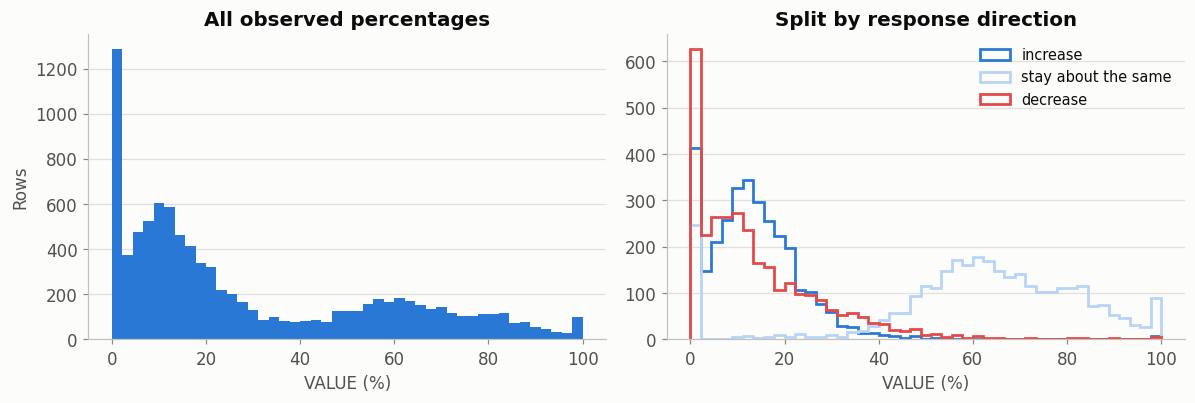

zeros: 1,043 rows  (11.1%)
median 17.6%   90th percentile 73.4%   max 100.0%


In [ ]:
values = pd.to_numeric(csbc_data["VALUE"], errors="coerce").dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(values, bins=45, color=csbc.SERIES_COLOR["Sales"], zorder=2)
axes[0].set_title("All observed percentages")
axes[0].set_xlabel("VALUE (%)")
axes[0].set_ylabel("Rows")

# 'stay about the same' dominates every question, so splitting by direction is the only
# way to see the increase/decrease distributions at all.
for direction in csbc.DIRECTION_ORDER:
    subset = pd.to_numeric(
        csbc_data.loc[csbc_data["Expected_change"] == direction, "VALUE"], errors="coerce"
    ).dropna()
    axes[1].hist(subset, bins=45, histtype="step", linewidth=1.8,
                 color=csbc.COMPOSITION_COLOR[direction], label=direction, zorder=2)
axes[1].set_title("Split by response direction")
axes[1].set_xlabel("VALUE (%)")
axes[1].legend(frameon=False, fontsize=9.5)

for ax in axes:
    ax.grid(axis="y")
    ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(csbc.OUTPUT_DIR / "eda_value_distribution.png")
plt.show()

print(f"zeros: {(values == 0).sum():,} rows  ({(values == 0).mean() * 100:.1f}%)")
print(f"median {values.median():.1f}%   90th percentile {values.quantile(0.9):.1f}%   max {values.max():.1f}%")

`stay about the same` sits far to the right of the other two: most businesses expect stability on
most questions. The spike at zero is the small-cell problem: **1,000+ rows read exactly 0%**, mostly
territories crossed with narrow industries. Any group-level conclusion has to keep that in view.

## Question 3: How do expectations move over time?

**Form: line.** Quarters are ordered, and the question is about progression.

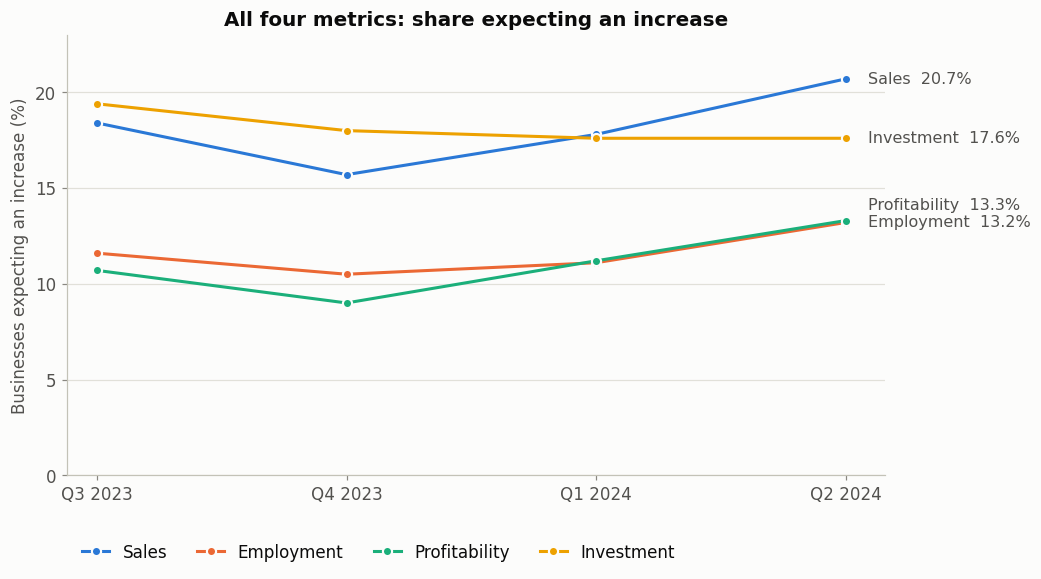

Business_information,Sales,Employment,Profitability,Investment
Quarter,,,,
Q3 2023,18.4,11.6,10.7,19.4
Q4 2023,15.7,10.5,9.0,18.0
Q1 2024,17.8,11.1,11.2,17.6
Q2 2024,20.7,13.2,13.3,17.6


In [ ]:
national = csbc.national_increase_chart(
    csbc_data, csbc.OUTPUT_DIR / "eda_national_trend.png",
    title="All four metrics: share expecting an increase",
)
national

Two things stand out and set up the analyses that follow: all four dipped in Q4 2023 and recovered,
**except investment, which kept drifting down**. Investment also sits at a *higher* level than
employment or profitability while behaving quite differently — another hint that it is not measuring
the same kind of thing.

## Question 4: Do the four metrics move together?

The data has to be reshaped first: one row per survey cell, one column per metric. Only then is
"do these move together" a question that can be computed.

**Form: heatmap** for all six pairs at once, then a **scatter** for the strongest pair.

In [ ]:
# One row per (geography x characteristic x quarter), one column per metric.
wide = csbc.metric_matrix(csbc_data)
print(f"{len(wide):,} survey cells with all four metrics observed and non-empty\n")
wide.head()

645 survey cells with all four metrics observed and non-empty



Business_information                                        Sales  Employment  Profitability  Investment
GEO     Business_characteristics                   Quarter                                              
Alberta Accommodation and food services            Q1 2024   15.1        20.2           16.0        47.5
                                                   Q2 2024   37.4        14.5           24.7        17.1
                                                   Q3 2023   37.4        14.7           12.6        28.4
                                                   Q4 2023   14.2         7.5            5.6        20.9
        Agriculture, forestry, fishing and hunting Q1 2024    2.8         2.0           23.1        20.4

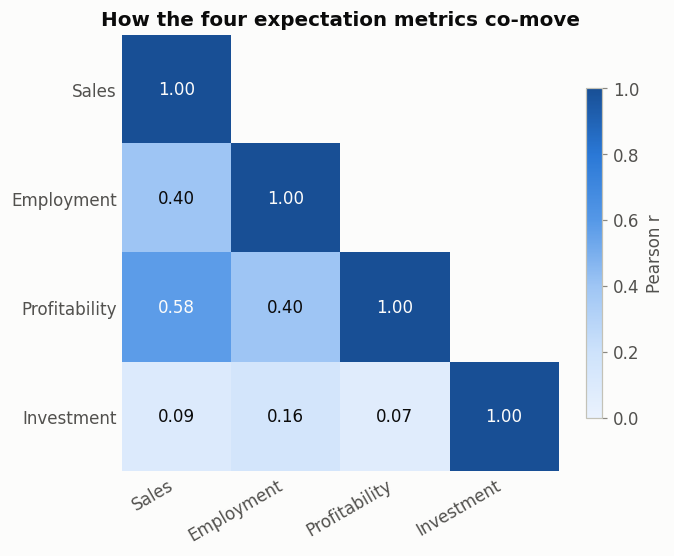

Business_information,Sales,Employment,Profitability,Investment
Business_information,,,,
Sales,1.00,0.40,0.58,0.09
Employment,0.40,1.00,0.40,0.16
Profitability,0.58,0.40,1.00,0.07
Investment,0.09,0.16,0.07,1.00


In [ ]:
correlations = csbc.metric_correlations(csbc_data)
csbc.correlation_heatmap(
    correlations, csbc.OUTPUT_DIR / "eda_metric_correlation.png",
    title="How the four expectation metrics co-move",
)
correlations

In [10]:
# Average association of each metric with the other three - the summary that matters.
# Averaged from the unrounded matrix; averaging already-rounded values shifts the result.
exact = csbc.metric_matrix(csbc_data).corr()
pd.DataFrame(
    {"mean r with others": [round(exact[m].drop(m).mean(), 2) for m in csbc.METRIC_ORDER]},
    index=csbc.METRIC_ORDER,
)

,mean r with others
Sales,0.36
Employment,0.32
Profitability,0.35
Investment,0.10


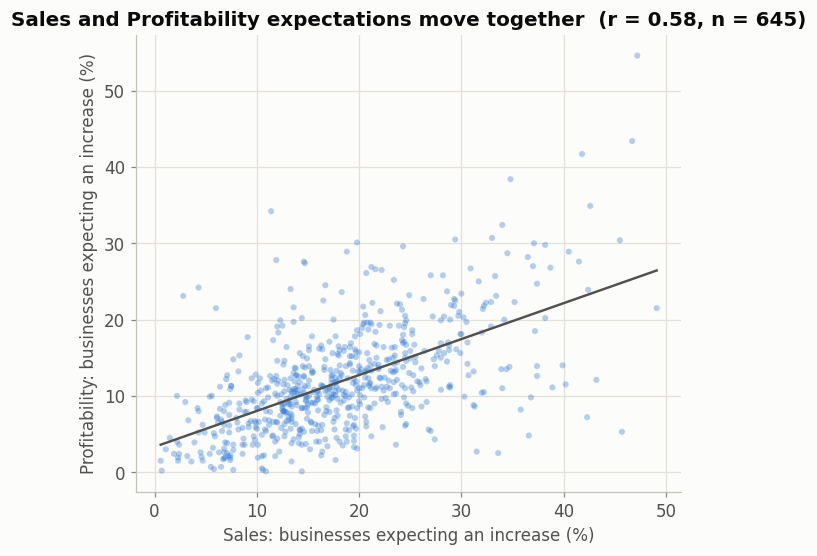

0.58

In [11]:
csbc.metric_scatter(csbc_data, "Sales", "Profitability",
                    csbc.OUTPUT_DIR / "eda_sales_profitability_scatter.png")

### What the correlations say

- **Sales ↔ Profitability is the strongest pair (r = 0.58).** Where businesses expect to sell more,
  they usually expect to earn more. That is the normal relationship: and it is what makes
  notebook `04` interesting, because in Q2 2024 the two point in *opposite* directions.
- **Employment sits in the middle** (r ≈ 0.40 with both), consistent with hiring following expected
  activity.
- **Investment is nearly independent of all three (mean r = 0.10).** It is not a lagging version of
  the operating cycle; it is a separate decision.

### What we do about it

Correlation is not just an observation here, it changes the analysis:

1. **No composite index.** Averaging sales, employment and profitability into one "confidence"
   number would triple-count one shared underlying factor and read as three independent
   confirmations. So the metrics stay separate.
2. **Investment gets analysed on its own terms.** Because it carries information the others do not,
   folding it into an operating bundle would hide the only genuinely independent signal in the data.
3. **Sales and profitability are never treated as two independent pieces of evidence.** When they
   agree, that is close to one finding, not two.

## Question 5: Are the three response shares mechanically linked?

If the three directions were a closed split of every respondent, then `increase` and `decrease`
would have to trade off against each other, strongly negatively correlated. Testing that decides
whether the missing values can be back-filled.

In [ ]:
csbc.direction_correlations(csbc_data)

,cells,"r(increase, decrease)","r(increase, same)"
metric,,,
Sales,752,-0.03,-0.34
Employment,749,-0.10,-0.43
Profitability,751,-0.08,-0.18
Investment,756,0.05,-0.26


`r(increase, decrease)` is essentially **zero** for every metric (−0.10 to +0.05). The three shares
are **not** a closed partition, so:

- `decrease = 100 − increase − stay about the same` is **not** a valid reconstruction, and
- the seven missing cells from notebook `01` stay missing.

This is the empirical basis for the preprocessing decision, rather than a stylistic preference.

## What this notebook establishes

1. **Investment is structurally different**: 16% of businesses give it no directional answer, and it
   is statistically independent of the other three metrics. Two separate lines of evidence.
2. **Sales and profitability are normally the tightest pair**: (r = 0.58), so any divergence between
   them is a genuine anomaly worth investigating.
3. **The three response shares are not a closed partition**, so nothing may be back-filled or
   rescaled.
4. **Small cells are everywhere**: over a thousand zero rows, so group-level findings need a
   volatility caveat.

These four points drive the three analyses that follow.

---

**Next:** `03_analysis_national_expectations.ipynb`: the national trend, and whether comparing
these metrics side by side is fair.

